In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

sys.path.append(os.path.join(os.getcwd(), '..'))
from config import RAW_DATA_PATH, TARGET, HINT_FEATURES

In [10]:
df = pd.read_csv(RAW_DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (9082, 3925)


,Unnamed: 0,F1,F2,F3,F4,F5,F6,F7,F8,F9,...,F3915,F3916,F3917,F3918,F3919,F3920,F3921,F3922,F3923,F3924
0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,1,0,0,1,0,0,1,0,0
1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,1,0,0,1,0,1,0,0,0
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,1,0,0,1,0,0,1,0,0
3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,1,0,0,1,0,0,1,0,0
4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,1,0,0,1,0,1,0,0,0


F3924
0    9001
1      81
Name: count, dtype: int64

Imbalance ratio  →  9001 legitimate : 81 fraud
Fraud percentage →  0.89%


<Axes: xlabel='F3924'>

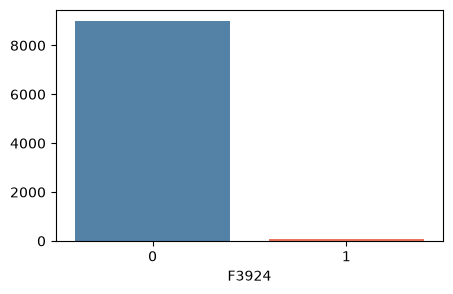

In [11]:
counts = df[TARGET].value_counts()
print(counts)
print(f"\nImbalance ratio  →  {counts[0]} legitimate : {counts[1]} fraud")
print(f"Fraud percentage →  {counts[1]/len(df)*100:.2f}%")

plt.figure(figsize=(5,3))
sns.barplot(
    x=counts.index.astype(str),
    y=counts.values,
    hue=counts.index.astype(str),
    palette=["steelblue", "tomato"],
    legend=False
)

Columns with > 50% missing:
1138

Top 20 columns by missing %:
       missing_count  missing_pct
F495            9082        100.0
F2968           9082        100.0
F3074           9082        100.0
F3077           9082        100.0
F2607           9082        100.0
F2552           9082        100.0
F2555           9082        100.0
F2707           9082        100.0
F390            9082        100.0
F2655           9082        100.0
F597            9082        100.0
F440            9082        100.0
F437            9082        100.0
F594            9082        100.0
F492            9082        100.0
F393            9082        100.0
F2971           9082        100.0
F3182           9082        100.0
F3503           9082        100.0
F3233           9082        100.0


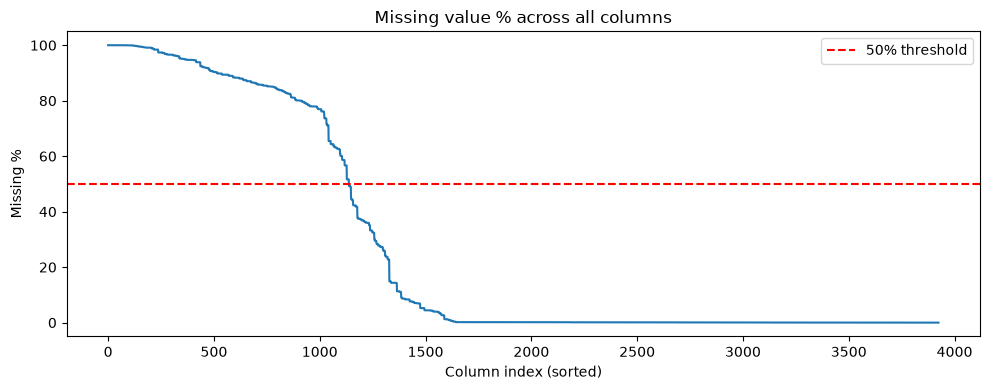

In [12]:
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df)) * 100

missing = pd.DataFrame({
    "missing_count": null_counts,
    "missing_pct"  : null_pct
}).sort_values("missing_pct", ascending=False)

print("Columns with > 50% missing:")
print(missing[missing["missing_pct"] > 50].shape[0])

print("\nTop 20 columns by missing %:")
print(missing.head(20))

# Plot
plt.figure(figsize=(10,4))
plt.plot(sorted(null_pct.values, reverse=True))
plt.axhline(y=50, color='red', linestyle='--', label='50% threshold')
plt.title("Missing value % across all columns")
plt.xlabel("Column index (sorted)")
plt.ylabel("Missing %")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/missing_values.png")
plt.show()

In [13]:
available = [f for f in HINT_FEATURES if f in df.columns]
missing_hints = [f for f in HINT_FEATURES if f not in df.columns]

print(f"Available hint features : {len(available)}")
print(f"Missing hint features   : {missing_hints}")

df[available + [TARGET]].describe().T

Available hint features : 18
Missing hint features   : []


,count,mean,std,min,25%,50%,75%,max
F115,8724.0,5.917240e-01,2.175059e-01,0.000000e+00,0.4500,0.53,7.000000e-01,1.000000e+00
F321,8997.0,1.152257e+00,3.976558e-01,0.000000e+00,1.0000,1.07,1.290000e+00,1.060000e+01
F527,8294.0,1.000445e+00,7.527936e-01,0.000000e+00,0.8300,1.00,1.130000e+00,4.842000e+01
F531,8441.0,1.438801e+00,9.020094e-01,0.000000e+00,1.0000,1.21,1.680000e+00,2.096000e+01
F670,9066.0,9.155085e-02,2.884068e-01,0.000000e+00,0.0000,0.00,0.000000e+00,1.000000e+00
F1692,9075.0,2.597245e-01,7.802972e-01,0.000000e+00,0.0000,0.00,0.000000e+00,1.400000e+01
F2082,9075.0,2.071110e-02,8.102217e-02,0.000000e+00,0.0000,0.00,0.000000e+00,1.000000e+00
F2122,9078.0,4.532418e-02,1.319583e-01,0.000000e+00,0.0000,0.00,1.242236e-02,1.000000e+00
F2582,5678.0,7.646354e-02,5.189253e-01,-8.800000e-01,-0.1300,0.00,1.300000e-01,1.889000e+01
F2678,6508.0,3.487480e+02,2.085927e+04,-9.100000e-01,-0.3300,-0.12,2.000000e-02,1.626944e+06


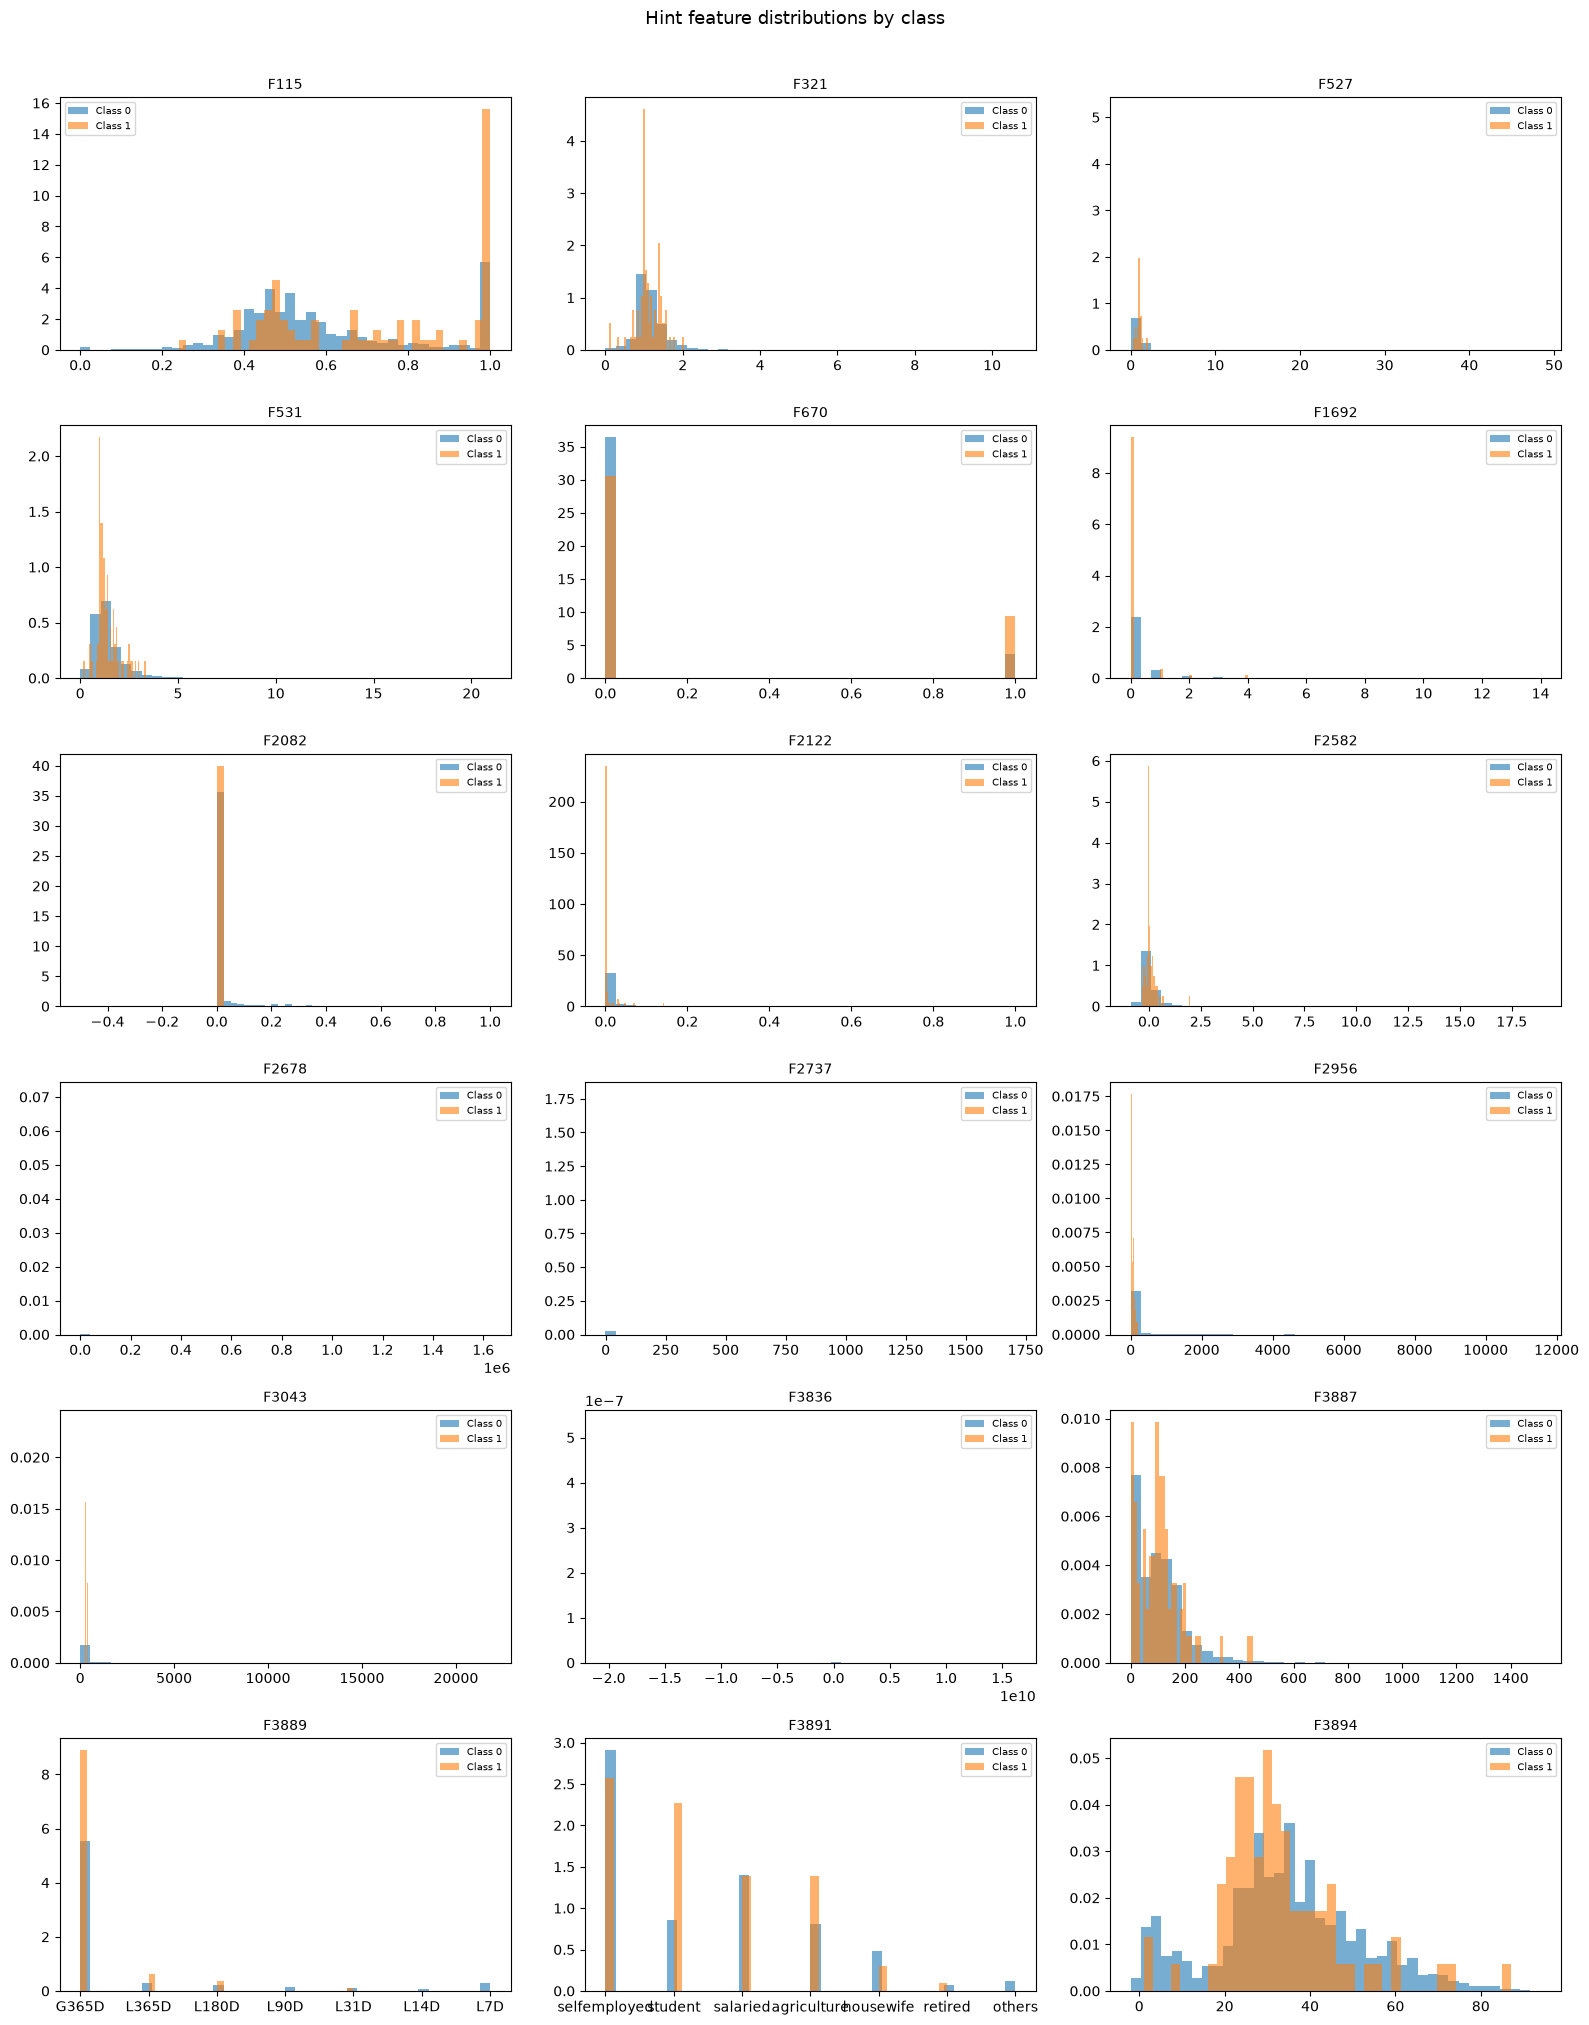

In [14]:
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(available):
    if i >= len(axes): break
    for label, grp in df.groupby(TARGET)[col]:
        axes[i].hist(grp.dropna(), bins=40, alpha=0.6,
                     label=f"Class {label}", density=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=7)

plt.suptitle("Hint feature distributions by class", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig("../reports/figures/hint_feature_distributions.png", bbox_inches='tight')
plt.show()

F115     float64
F321     float64
F527     float64
F531     float64
F670     float64
F1692    float64
F2082    float64
F2122    float64
F2582    float64
F2678    float64
F2737    float64
F2956    float64
F3043    float64
F3836    float64
F3887      int64
F3889        str
F3891        str
F3894    float64
F3924      int64
dtype: object


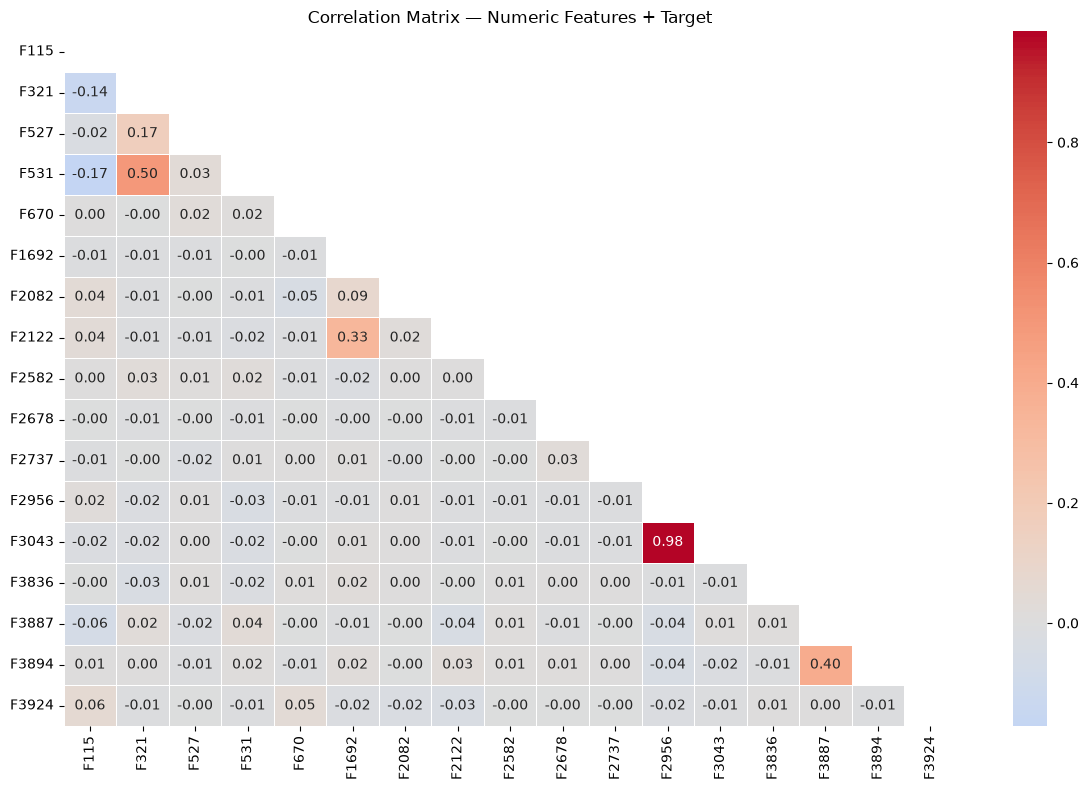

In [16]:
selected = available + [TARGET]

print(df[selected].dtypes)

plt.figure(figsize=(12, 8))

# Select only numeric columns
corr_df = df[available + [TARGET]].select_dtypes(include=["number"])

corr = corr_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix — Numeric Features + Target")
plt.tight_layout()
plt.savefig("../reports/figures/correlation_heatmap.png")
plt.show()

In [17]:
print("===== EDA SUMMARY =====")
print(f"Total rows              : {df.shape[0]}")
print(f"Total columns           : {df.shape[1]}")
print(f"Fraud cases             : {counts[1]}")
print(f"Legit cases             : {counts[0]}")
print(f"Imbalance ratio         : 1 : {counts[0]//counts[1]}")
print(f"Columns > 50% missing   : {missing[missing['missing_pct']>50].shape[0]}")
print(f"Hint features available : {len(available)} / {len(HINT_FEATURES)}")

===== EDA SUMMARY =====
Total rows              : 9082
Total columns           : 3925
Fraud cases             : 81
Legit cases             : 9001
Imbalance ratio         : 1 : 111
Columns > 50% missing   : 1138
Hint features available : 18 / 18
